In [1]:
change_point_output = pd.DataFrame({
    "change_point_index":[tau_mode],
    "change_point_date":[change_date_mode],
    "mean_before":[mu_before_mean],
    "mean_after":[mu_after_mean],
    "absolute_change":[absolute_change],
    "percentage_change":[percentage_change]
})

change_point_output.to_csv(
    "../data/processed/change_point_results.csv",
    index=False
)

change_point_output

NameError: name 'pd' is not defined

In [2]:
print("tau_mode:", tau_mode)
print("change_date_mode:", change_date_mode)

print("mu_before_mean:", mu_before_mean)
print("mu_after_mean:", mu_after_mean)

print("absolute_change:", absolute_change)
print("percentage_change:", percentage_change)

NameError: name 'tau_mode' is not defined

In [3]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (15, 6)

RANDOM_SEED = 42

print("Libraries imported successfully.")

g++ not available, if using conda: `conda install gxx`


Libraries imported successfully.


In [4]:
data_path = Path("../data/raw/BrentOilPrices.csv")

df = pd.read_csv(data_path)

df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%b-%y",
    errors="coerce"
)

df["Price"] = pd.to_numeric(
    df["Price"],
    errors="coerce"
)

df = (
    df.dropna(subset=["Date", "Price"])
      .drop_duplicates(subset=["Date"])
      .sort_values("Date")
      .reset_index(drop=True)
)

print("Dataset shape:", df.shape)
print("Date range:", df["Date"].min(), "to", df["Date"].max())

df.head()

Dataset shape: (8360, 2)
Date range: 1987-05-20 00:00:00 to 2020-04-21 00:00:00


,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [5]:
monthly_df = (
    df.set_index("Date")["Price"]
      .resample("MS")
      .mean()
      .dropna()
      .reset_index()
)

monthly_df.columns = ["Date", "Price"]

prices = monthly_df["Price"].values.astype("float64")
time_index = np.arange(len(monthly_df))

print("Monthly observations:", len(monthly_df))
monthly_df.head()

Monthly observations: 396


,Date,Price
0,1987-05-01,18.580000
1,1987-06-01,18.860476
2,1987-07-01,19.856522
3,1987-08-01,18.979524
4,1987-09-01,18.313182


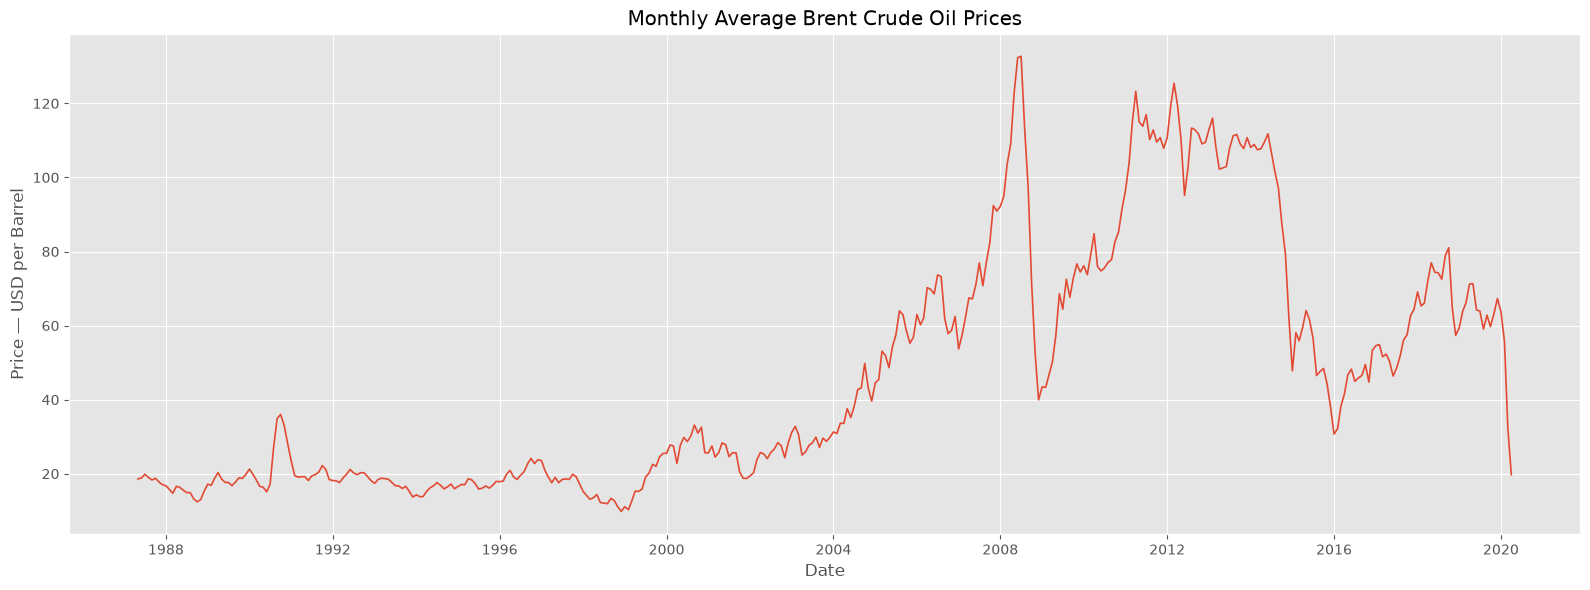

In [6]:
plt.figure(figsize=(16, 6))

plt.plot(
    monthly_df["Date"],
    monthly_df["Price"],
    linewidth=1.2
)

plt.title("Monthly Average Brent Crude Oil Prices")
plt.xlabel("Date")
plt.ylabel("Price — USD per Barrel")
plt.tight_layout()
plt.show()

In [7]:
with pm.Model() as change_point_model:

    tau = pm.DiscreteUniform(
        "tau",
        lower=1,
        upper=len(prices) - 2
    )

    mu_before = pm.Normal(
        "mu_before",
        mu=prices.mean(),
        sigma=prices.std() * 2
    )

    mu_after = pm.Normal(
        "mu_after",
        mu=prices.mean(),
        sigma=prices.std() * 2
    )

    sigma = pm.HalfNormal(
        "sigma",
        sigma=prices.std()
    )

    expected_mean = pm.math.switch(
        time_index < tau,
        mu_before,
        mu_after
    )

    observed_prices = pm.Normal(
        "observed_prices",
        mu=expected_mean,
        sigma=sigma,
        observed=prices
    )

print("Model created successfully.")

Model created successfully.


In [8]:
with change_point_model:

    step_continuous = pm.NUTS(
        vars=[mu_before, mu_after, sigma],
        target_accept=0.90
    )

    step_discrete = pm.Metropolis(
        vars=[tau]
    )

    trace = pm.sample(
        draws=1200,
        tune=800,
        chains=2,
        cores=1,
        step=[step_continuous, step_discrete],
        random_seed=RANDOM_SEED,
        return_inferencedata=True,
        progressbar=True
    )

Sequential sampling (2 chains in 1 job)
CompoundStep
>NUTS: [mu_before, mu_after, sigma]
>Metropolis: [tau]


Output()

Sampling 2 chains for 800 tune and 1_200 draw iterations (1_600 + 2_400 draws total) took 19 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [9]:
summary = az.summary(
    trace,
    var_names=["tau", "mu_before", "mu_after", "sigma"],
    round_to=3
)

summary

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tau,214.215,2.013,211.000,218.000,359.454,427.743,1.017,0.110,0.095
mu_before,21.467,1.300,19.360,23.531,2026.944,1592.270,1.000,0.029,0.020
mu_after,76.000,1.392,73.726,78.168,1655.136,1538.442,1.002,0.034,0.024
sigma,17.938,0.641,16.936,18.975,2315.727,1897.942,1.000,0.013,0.009


In [10]:
tau_samples = trace.posterior["tau"].values.flatten()
mu_before_samples = trace.posterior["mu_before"].values.flatten()
mu_after_samples = trace.posterior["mu_after"].values.flatten()

tau_mode = int(pd.Series(tau_samples).mode().iloc[0])
change_date_mode = monthly_df.loc[tau_mode, "Date"]

mu_before_mean = mu_before_samples.mean()
mu_after_mean = mu_after_samples.mean()

absolute_change = mu_after_mean - mu_before_mean
percentage_change = (
    absolute_change / mu_before_mean
) * 100

probability_increase = np.mean(
    mu_after_samples > mu_before_samples
)

probability_decrease = np.mean(
    mu_after_samples < mu_before_samples
)

before_interval = np.quantile(
    mu_before_samples,
    [0.025, 0.975]
)

after_interval = np.quantile(
    mu_after_samples,
    [0.025, 0.975]
)

print("Detected change point:", change_date_mode.strftime("%Y-%m-%d"))
print(f"Mean before: ${mu_before_mean:.2f}")
print(f"Mean after: ${mu_after_mean:.2f}")
print(f"Absolute change: ${absolute_change:.2f}")
print(f"Percentage change: {percentage_change:.2f}%")
print(f"Probability of increase: {probability_increase:.2%}")
print(f"Probability of decrease: {probability_decrease:.2%}")

Detected change point: 2005-03-01
Mean before: $21.47
Mean after: $76.00
Absolute change: $54.53
Percentage change: 254.04%
Probability of increase: 100.00%
Probability of decrease: 0.00%


In [13]:
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

monthly_df.to_csv(
    output_dir / "monthly_prices.csv",
    index=False
)

change_point_output = pd.DataFrame({
    "change_point_index": [tau_mode],
    "change_point_date": [
        change_date_mode.strftime("%Y-%m-%d")
    ],
    "mean_before": [mu_before_mean],
    "mean_after": [mu_after_mean],
    "absolute_change": [absolute_change],
    "percentage_change": [percentage_change],
    "probability_increase": [probability_increase],
    "probability_decrease": [probability_decrease],
    "before_lower_95": [before_interval[0]],
    "before_upper_95": [before_interval[1]],
    "after_lower_95": [after_interval[0]],
    "after_upper_95": [after_interval[1]]
})

change_point_output.to_csv(
    output_dir / "change_point_results.csv",
    index=False
)


print("Outputs saved successfully.")
change_point_output

Outputs saved successfully.


,change_point_index,change_point_date,mean_before,mean_after,absolute_change,percentage_change,probability_increase,probability_decrease,before_lower_95,before_upper_95,after_lower_95,after_upper_95
0,214,2005-03-01,21.466522,75.999512,54.532989,254.037373,1.0,0.0,18.911163,23.97312,73.234444,78.620169
